In [1]:
#julia version:1.11.6
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles

In [7]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,"cheb")
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end

eigsol (generic function with 1 method)

In [8]:
N_cheb = 199
Ro = -1
Tw = 1
Mr = 0.1
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = -0.05
num = 1
omega = 0.079
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
R = 100
Ma = Mr/R
eigval1,eigvec1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.2,num)
eigval1

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

MethodError: MethodError: no method matching Spatial_mode_BEK(::Matrix{Float64}, ::Matrix{Float64}, ::Matrix{Float64}, ::Matrix{Float64}, ::Matrix{Float64}, ::Matrix{Float64}, ::Matrix{Float64}, ::Float64, ::Float64, ::Int64, ::Float64, ::Int64, ::Int64, ::Int64, ::Matrix{Float64}, ::Matrix{Float64})
The function `Spatial_mode_BEK` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  Spatial_mode_BEK(::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, !Matched::Any, !Matched::Any)
   @ Main ~/main/code/compress/compressible_bek/compress/BEK/Ro=0.687/CRD_STA.jl:722


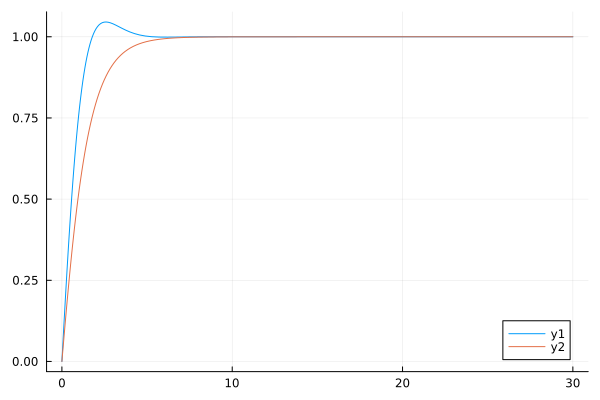

In [5]:
plot!(x,G)

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,z,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
    sigma = 0.72
    gamma = 1.4
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    return eigval
end

In [ ]:
##DIRECTLY CACULATE CUR
##initial
# for omega = [0.048,0.024,-0.024,-0.048]
function cur(Tw,Mr,Ro,omega,R_ini)

    N_cheb = 69
    gamma = 1.4
    sigma = 0.72
    R_ini = 200
    R_step = 0.4
    be_ini = 0.04
    be_step = -0.0008
    num = 1
    c_ini = 0.06
    Co = 2-Ro-Ro^2
    Ma = Mr/R_ini
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    initial = []
    tempvec = [0 0 0 0 0]
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini)
    if imag(eigval[1]) < 0
        for be = be_ini : be_step : 0
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini)
            point = filter(x -> abs(imag(x)) < 0.0005 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : -be_step : 0.5
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini)
            point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    end
    total = initial

 # CACULATE

    for be = initial[end,3] +  be_step  :  -1 * be_step : 0.4

        # if total_i[end,2] <40
        #     num = 5
        # else
        #     num = 1
        # end
        num = 1

        c = total[end,4] - im * total[end,5]
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be+2*be_step,N_cheb,Ro,Co,D,D2,c)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be-2*be_step,N_cheb,Ro,Co,D,D2,c)

        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            mode = 2

        end
        
        if mode == 1 



            for R = total[end,2] : R_step : 600

                Ma = Mr/R

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                Ma = Mr/R
                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 1
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end

        if mode == 1
            
            for R = total[end,2]: R_step : 600
                Ma = Mr/R

                if total[end,3] == be

                    break

                end 

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end

        if total[end,2] > R_ini + 10 && size(total,1)>40
            break
        end
    end
    writedlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat",total)
 end

┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\a5703\.julia\packages\SciMLBase\THas4\src\integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase